**Raquel del Valle Olivares y Xiya Ye**

![LogoUC3M](https://login.uc3m.es/imgs/uc3m.png)

In [1]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Gráficos
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram
import scipy.cluster.hierarchy as sch

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

# Semilla base
SEMILLA = 522214

## 0. Carga y exploración de datos

Lo primero que haremos es cargar el dataset de estrellas y realizar una exploración inicial para entender su estructura, lo tipos de variables y la calidad de los datos.

In [2]:
# Carga de datos
datos = pd.read_csv('stars_data.csv')
datos.head()

# Información general del dataser: tipos de variables y valores no nulos
datos.info()

# Estadísticas descriptivas de las variables numéricas
datos.describe()

# Valores únicos de las variables categóricas
print(f"\nValores únicos en 'Color' ({datos['Color'].nunique()} distintos):")
print(sorted(datos['Color'].unique()))

print(f"\nValores únicos en 'Spectral_Class' ({datos['Spectral_Class'].nunique()} distintos):")
print(sorted(datos['Spectral_Class'].unique()))

# Comprobamos que no hay valores nulos
nulos = datos.isnull().sum()
if nulos.sum() == 0:
    print("\nNo hay valores nulos en ninguna columna.")
else:
    print(nulos[nulos > 0])
#

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 11.4+ KB

Valores únicos en 'Color' (17 distintos):
['Blue', 'Blue White', 'Blue white', 'Blue-White', 'Blue-white', 'Orange', 'Orange-Red', 'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish', 'Yellowish', 'Yellowish White', 'white', 'yellow-white', 'yellowish']

Valores únicos en 'Spectral_Class' (7 distintos):
['A', 'B', 'F', 'G', 'K', 'M', 'O']

No hay valores nulos en ninguna columna.


El dataset contiene 240 estrellas y 5 variables: cuatro numéricas (`Temperature`, `L`, `R`, `A_M`) y dos categóricas (`Color` y `Spectral_Class`). No hay valores nulos por lo que no necesitamos imputación.

Observamos que la variable `Color` presenta variantes inconsistendes (diferencias de mayúsculas, guiones y espacios) que representan el mismo color. Las corregiremos a continuación.

## 1. Preprocesamiento: Codificación Ordinal de Variables Categóricas

Antes de aplicar el PCA y los algoritmos de clustering, necesitamos convertir las dos variables categóricas del dataser (`Color` y `Spectral_Class`) a valores numéricos. Haremos una codificación ordinal que respete un orden con significado físico.

### Justificación del orden
- **`Spectral_Class`**: La secuencia espectral O -> B -> A -> F -> G -> K -> M va de las estrellas más calientes a las más frías. Este orden es un estándar reconocido en astronomía (clasificación de Harvard), por lo que usaremos este mismo orden directamente.

- **`Color`**: El color de una estrella está directamente relacionado con su temperatura superficial. Para determinar el orden correcto y detectar variantes inconsistentes, analizamos la temperatura media y la clase espectral más frecuente de cada valor único antes de codificar.

In [3]:
# Análisis de las variantes de Color antes de codificar

# Temperatura media y otras variables físicas por color
print("Temperatura media por variante de Color (ordenada de mayor a menor):")
print(datos.groupby('Color')[['Temperature', 'L', 'R', 'A_M']]
      .mean()
      .sort_values('Temperature', ascending=False))

# Clase espectral más frecuente por color
print("\nClase espectral más frecuente por variante de Color:")
print(datos.groupby('Color')['Spectral_Class']
      .agg(lambda x: x.value_counts().index[0]))

Temperatura media por variante de Color (ordenada de mayor a menor):
                     Temperature              L            R        A_M
Color                                                                  
Blue                21918.339286  249974.732446   214.802452  -2.382446
Blue-white          18669.923077  108655.500000   292.892538  -3.611962
Blue White          14638.900000       0.007491     0.010459  12.121000
white               12460.666667       0.000283     0.009113  13.213333
Yellowish White     10826.666667       0.000115     0.011213  13.096667
Blue white          10576.500000       0.000617     0.009230  13.320000
Blue-White           8945.000000      38.000000     2.487000   0.120000
Whitish              8876.000000      41.350000     2.345000   1.290000
White                8545.857143  134633.285920   362.150189   6.802857
Pale yellow orange   7230.000000       0.000080     0.013000  14.080000
White-Yellow         7100.000000       0.000290     0.012000  14.09

El análisis nos revela 2 decisiones clave:

1. **Fusión de categorías amarillo-blanco**: Las variantes `Yellowish-White`, `White-Yellow` y `Pale-Yellow-Orange` presentan temperaturas medias casi identicas (entrre 6.985K y 7230K) y comparten exactamente la misma clase espectral (F). Esto inidica que son denominaciones distintas del mismo tipo físico de estrella, por lo que las fusionamos en una única cateforía `Yellow-White`.

2. **Orden físico confirmado**: El resto de categorías presentan diferencias de temperatura claras y clases espectrales fistintas, confirmando el orden natural: Blue (O) -> Blue-White (B) -> White (A) -> Yellow-White (F) -> Orange-Red (K) -> Orange (M) -> Red (M)

In [4]:
# Unificación de variantes inconsistentes en 'Color'

# Primero limpiamos espacios extra y normalizamos el tipo de string
datos['Color'] = datos['Color'].str.strip()

# Mapeamos cada variante a una etiqueta canónica
mapa_colores = {
    # Azul
    'Blue':               'Blue',
    # Azul-blanco
    'Blue White':         'Blue-White',
    'Blue white':         'Blue-White',
    'Blue-white':         'Blue-White',
    'Blue-White':         'Blue-White',
    # Blanco
    'White':              'White',
    'white':              'White',
    'Whitish':            'White',
    # Amarillo-blanco: fusionamos porque comparten clase espectral F
    'White-Yellow':       'Yellow-White',
    'Yellowish White':    'Yellow-White',
    'yellowish':          'Yellow-White',
    'Yellowish':          'Yellow-White',
    'yellow-white':       'Yellow-White',
    'Pale yellow orange': 'Yellow-White',
    # Naranja-rojo
    'Orange-Red':         'Orange-Red',
    # Naranja
    'Orange':             'Orange',
    # Rojo
    'Red':                'Red',
}

datos['Color'] = datos['Color'].map(mapa_colores)

print(f"Valores nulos tras el mapeo: {datos['Color'].isnull().sum()}")
print("\nValores únicos de 'Color' tras la unificación:")
print(sorted(datos['Color'].dropna().unique()))

Valores nulos tras el mapeo: 0

Valores únicos de 'Color' tras la unificación:
['Blue', 'Blue-White', 'Orange', 'Orange-Red', 'Red', 'White', 'Yellow-White']


In [5]:
# Codificación ordinal de 'Color' y 'Spectral_Class'

# Orden de Color: de más caliente (azul) a más fría (rojo)
orden_color = [
    'Blue',         # ~21.918 K — clase O
    'Blue-White',   # ~16.660 K — clase B
    'White',        #  ~9.580 K — clase A
    'Yellow-White', #  ~7.100 K — clase F
    'Orange-Red',   #  ~5.112 K — clase K
    'Orange',       #  ~4.018 K — clase M
    'Red',          #  ~3.292 K — clase M
]

# Orden de Spectral_Class: de más caliente (O) a más fría (M)
# Estándar astronómico de la clasificación de Harvard
orden_spectral = ['O', 'B', 'A', 'F', 'G', 'K', 'M']

# Aplicamos OrdinalEncoder con los órdenes definidos
encoder = OrdinalEncoder(
    categories = [orden_color, orden_spectral]
)

datos[['Color', 'Spectral_Class']] = encoder.fit_transform(
    datos[['Color', 'Spectral_Class']]
)

print("Dataset tras la codificación ordinal:")
datos.head()

Dataset tras la codificación ordinal:


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,6.0,6.0
1,3042,0.000500,0.1542,16.60,6.0,6.0
2,2600,0.000300,0.1020,18.70,6.0,6.0
3,2800,0.000200,0.1600,16.65,6.0,6.0
4,1939,0.000138,0.1030,20.06,6.0,6.0


Tras la codificación, las variables `Color` y `Spectral_Class` son ahora numéricas y respetan el orden físico establecido por la temperatura estelar. El resultado es una escala de 7 colores canínicos (de `Blue = 0` a `Red = 6`) y 7 clases espectrales (de `O = 0` a `M = 6`), ambas justificadas con los datos del propio dataset. A partir de aquí, todas las variables son numéricas y estamos listos para aplicar el PCA.

## 2. Reducción de dimensionalidad: PCA a 2 componentes

Para facilitar tanto la visualización como la tarea de clusteriing, vamos a reducir los datos a 2 dimensiones PCA (Principal Component Analysis). Los algoritmos de clustering se aplicarán directamente sobre estas dos componentes principales.

Antes de aplicar PCA, es fundamenteal escalar los datos con `StandardScaler`, por dos motivos: 
- **Escalado**: PCA es sensible a la magnitud de las variables. Sin escalar, variables como `Temperature`(en miles de grados) dominarçian completamente el análisis frente a variables como `R` (en unidades solares).

- **Centrado**: `StandardScaler` centra los datos en (0.0), requisito matemático del PCA.

In [6]:
# Extraemos todas las columnas como matriz de features
X = datos.values 

# Pipeline definitivo: StandardScaler + PCA(2 componentes)
pipeline_pca = Pipeline([
    ('scaler', StandardScaler()),       # Siempre escalar antes de PCA
    ('pca', PCA(n_components=2))
])

# Transformamos los datos a 2 dimensiones
X_pca = pipeline_pca.fit_transform(X)
pca   = pipeline_pca.named_steps['pca']

print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Varianza total explicada:   {pca.explained_variance_ratio_.sum():.2%}")

Varianza explicada por PC1: 55.67%
Varianza explicada por PC2: 29.63%
Varianza total explicada:   85.30%


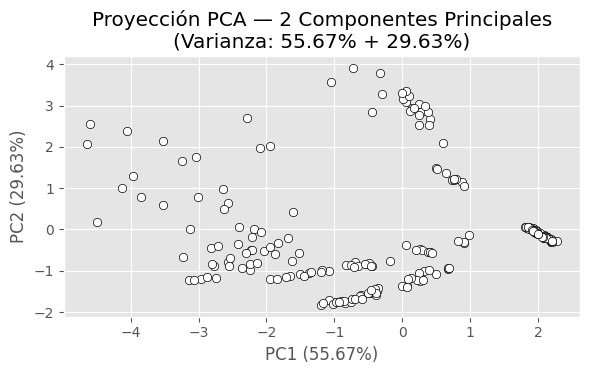

In [7]:
# Visualización de los datos proyectados en 2D
fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))

ax.scatter(
    x         = X_pca[:, 0],
    y         = X_pca[:, 1],
    c         = 'white',
    marker    = 'o',
    edgecolor = 'black'
)

ax.set_title(
    'Proyección PCA — 2 Componentes Principales\n'
    f'(Varianza: {pca.explained_variance_ratio_[0]:.2%} + '
    f'{pca.explained_variance_ratio_[1]:.2%})'
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.tight_layout()
plt.show()

La proyección en 2D nos permite intuir visualmente la estructura del dataset. A simple vista pueden apreciarse agrupaciones naturales de estrellas, lo que sugiere que los algoritmos de clustering tendrán buenos resultados.

A partir de aquí, todos los algoritmos de clustering trabajarán directamente sobre `X_pca`, la matriz de 240 estrellas x 2 componentes principales.

## 3. Algoritmos de clustering
### 3.1. Clustering: K-Means
K-Means es un algoritmo de clustering basado en centroides. Asume que los datos se agrupan en K clusters (hiperparámetro que fijaremos más adelante), y busca los K centroides que minimizan la suma de distancias euclídeas de cada punto a su centroide más cercano.

Para determinar el número de K clusters en los que hay que agrupar, usaremos dos métodos:
- **Método del codo (Elbow)**: representa la inercia para distintos valores de K. El punto donde la reducción de inercia se ralentiza indica el K óptimo.

- **Coeficiente Silhouette**: mide, para cada punto, si se parece más a su propio cluster que al más cercano. Valores entre -1 y +1, cuanto mayor mejor. 

Combinaremos ambos métodos para seleccionar el K óptimo final.

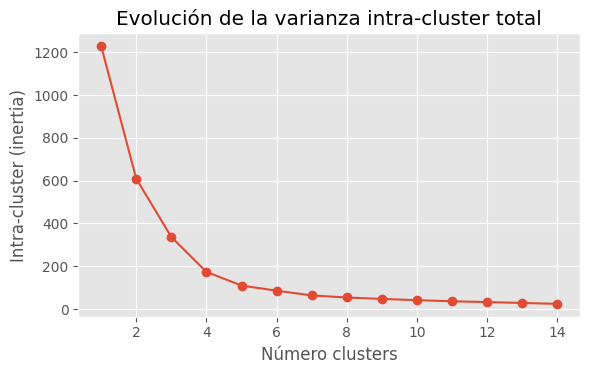

In [8]:
# Método elbow para identificar el número óptimo de clusters

range_n_clusters = range(1, 15)
inertias = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
        n_clusters   = n_clusters,
        n_init       = 20,
        random_state = SEMILLA
    )
    modelo_kmeans.fit(X_pca)
    inertias.append(modelo_kmeans.inertia_)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, inertias, marker='o')
ax.set_title('Evolución de la varianza intra-cluster total')
ax.set_xlabel('Número clusters')
ax.set_ylabel('Intra-cluster (inertia)')
plt.tight_layout()
plt.show()

El gráfico del codo muestra una caída muy pronunciada de la inercia entre K=1 y K=2, seguida de reducciones cada vez más pequeñas. El "codo" más claro se encuentra en K=2, aunque se aprecia una segunda inflexión suave al rededor de K=5-6 donde la curva vuelve a aplanarse.

Dado que el codo visual no es completamente concluyente, usaremos el coeficiente de Silhouette para confirmar el número óptimo de clusters.

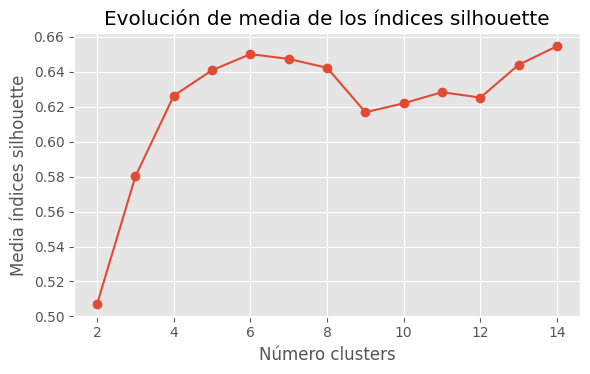

In [9]:
# Método silhouette para identificar el número óptimo de clusters

range_n_clusters = range(2, 15)
valores_medios_silhouette = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
        n_clusters   = n_clusters,
        n_init       = 20,
        random_state = SEMILLA
    )
    cluster_labels = modelo_kmeans.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    valores_medios_silhouette.append(silhouette_avg)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, valores_medios_silhouette, marker='o')
ax.set_title('Evolución de media de los índices silhouette')
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette')
plt.tight_layout()
plt.show()


El coeficiente Silhouette alcanza su valor máximo en K=14, sin embargo, un número tan elevado de clusters es poco interpretable. Pero también alcanza un valor casi del máximo en k=6.

Combinando ambos métodos: el codo mostraba una primera inflexión clara en K=2 y una segunda más suave en torno a K=5-6, y el Silhouette presenta un máximo local destacado en K=6, muy similar al máximo glbal. 

Por estos motivos elegimos **K=6** como número óptimo ya que es el punto donde convergen ambos métodos, ofrece una estructura interpretable y si calidad de clustering es practicamente igual a la del máximo global.

Usaremos por tanto K=6 para el modelo final de K-Means.

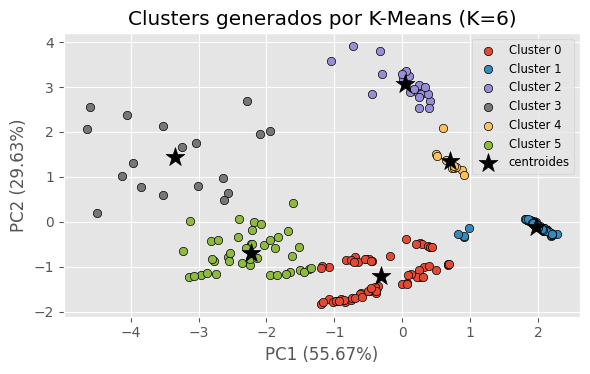

K-Means con K=6
Inercia:          85.9678
Silhouette score: 0.6501


In [10]:
# Modelo final K-Means con el K óptimo

K_KMEANS = 6

modelo_kmeans_final = KMeans(
    n_clusters   = K_KMEANS,
    n_init       = 25,
    random_state = SEMILLA
)
modelo_kmeans_final.fit(X_pca)

# Etiquetas de cluster para cada estrella
labels_kmeans = modelo_kmeans_final.labels_

# Visualización de los clusters generados
fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))

for i in np.unique(labels_kmeans):
    ax.scatter(
        x         = X_pca[labels_kmeans == i, 0],
        y         = X_pca[labels_kmeans == i, 1],
        marker    = 'o',
        edgecolor = 'black',
        label     = f'Cluster {i}'
    )

ax.scatter(
    x      = modelo_kmeans_final.cluster_centers_[:, 0],
    y      = modelo_kmeans_final.cluster_centers_[:, 1],
    c      = 'black',
    s      = 200,
    marker = '*',
    label  = 'centroides'
)

ax.set_title(f'Clusters generados por K-Means (K={K_KMEANS})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.legend(loc= 'upper right', fontsize='small')
plt.tight_layout()
plt.show()

# Métricas del modelo final
silhouette_kmeans = silhouette_score(X_pca, labels_kmeans)
print(f"K-Means con K={K_KMEANS}")
print(f"Inercia:          {modelo_kmeans_final.inertia_:.4f}")
print(f"Silhouette score: {silhouette_kmeans:.4f}")

**Conclusiones de K-Means**

K-Means ha identificado 6 clusters en el espacio PCA con un Silhouette score de 0.6501 y una inercia del 85.9678, lo que indica una separación razonablemente buena entre grupos.

Observando la visualización, podemos distinguir entre clusters con características muy distintas:
- Algunos clusters son muy compactos y bien definidos, por ejemplo, el Cluster 1 (azul) en la zona de abajo-derecha y el Cluster 4 (amarillo) en la cona central-derecha, lo que suguiere tipos de estrellas muy homogéneos.

- Otros clusters, como el Cluster 3 (gris) y el Cluster 5 (verde), son más dispersos y se solapan parcialmente en el espacio PCA, lo que indica grupos más heterogéneos o con mayor variabilidad interna.

Sin embargo, K-Means presenta una limitación importante: asume que los clusters tienen forma esférica y tamaños similares. La dispersión irregular que observamos en algunos clusters siguiere que esta asunción no se cumple del todo, lo que podría estar afectando a la calidad de la agrupación. Comprobaremos si el Clustering Jerárquico y DBSCAN obtienen una separación más natural.

### 3.2. Clustering: Jerárquico (Dendrogramas)
El clustering jerárquico construye una jerarquía de clusters de abajo habia arriba: empieza tratando cada estrella como un cluster individual y va fusionando los dos más cercanos en cada paso, hasta que todos pertenecen a un único cluster. El resultado se visualiza en un dendrograma, cuya altura en cada fusión representa la distancia entre los clusters unidos.

A diferenca del K-Means, no necesitamos especificar el número de clusters de antemano, podemos hacerlo al final "cortando" el dendrograma a una determinada altura.

Para la elección del linkage, probaremos los tres más habituales:
- **`ward`**: minimiza la varianza total intra-cluster en cada fusión. Produce clusters compactos y es el más robusto al ruido.

- **`complete`**: usa la distancia máxima entre puntos de dos clusters (más conservador). 

- **`ward`**: usa la distancia media entre todos los pares de puntos de dos clusters (aquilibrio entre los anteriores). 

Evaluaremos los 3 visualmente mediante dendrogramas y cuantitativamente con el coeficiente Silhouette, para quedarnos con el mejor.

In [11]:
# Función auxiliar para construir y dibujar dendrogramas

def plot_dendrogram(model, **kwargs):
    '''
    Esta función extrae la información de un modelo AgglomerativeClustering
    y representa su dendograma con la función dendrogram de scipy.cluster.hierarchy
    '''
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

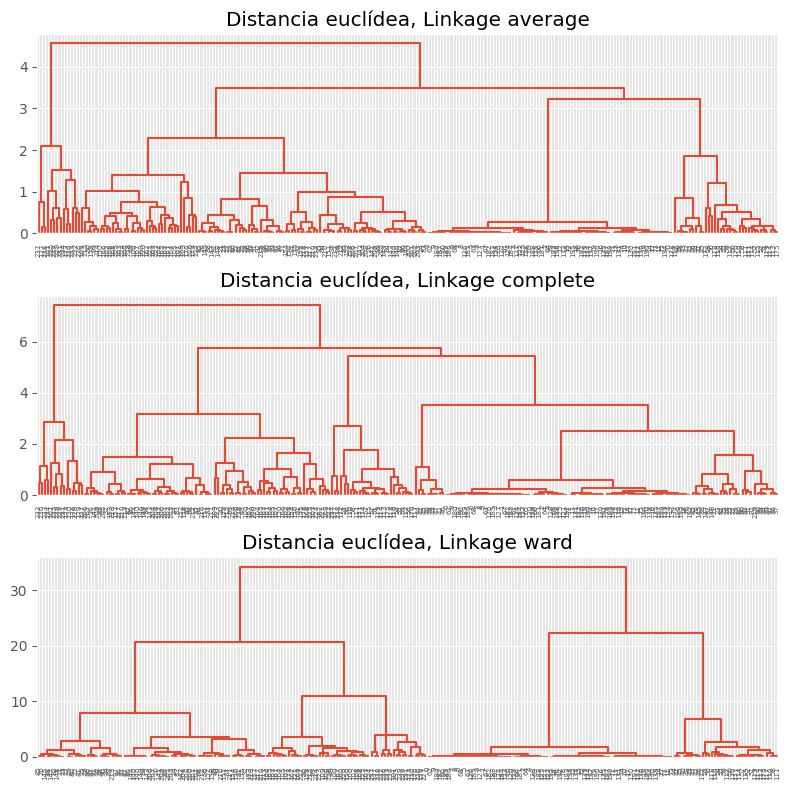

In [12]:
# Modelos jerárquicos con los tres linkages

modelo_hclust_average = AgglomerativeClustering(
    metric             = 'euclidean',
    linkage            = 'average',
    distance_threshold = 0,
    n_clusters         = None
)
modelo_hclust_average.fit(X=X_pca)

modelo_hclust_complete = AgglomerativeClustering(
    metric             = 'euclidean',
    linkage            = 'complete',
    distance_threshold = 0,
    n_clusters         = None
)
modelo_hclust_complete.fit(X=X_pca)

modelo_hclust_ward = AgglomerativeClustering(
    linkage            = 'ward',
    distance_threshold = 0,
    n_clusters         = None
)
modelo_hclust_ward.fit(X=X_pca)


# Dendrogramas comparativos

fig, axs = plt.subplots(3, 1, figsize=(8, 8))

plot_dendrogram(modelo_hclust_average, color_threshold=0, ax=axs[0])
axs[0].set_title('Distancia euclídea, Linkage average')

plot_dendrogram(modelo_hclust_complete, color_threshold=0, ax=axs[1])
axs[1].set_title('Distancia euclídea, Linkage complete')

plot_dendrogram(modelo_hclust_ward, color_threshold=0, ax=axs[2])
axs[2].set_title('Distancia euclídea, Linkage ward')

plt.tight_layout()
plt.show()

Observando los tres dendrogramas podemos extraer las siguientes conclusiones:
- **Linkage Average**: muestra una estructura desequilibrada, con un grupo muy grande que se fusiona a alturas bajas y algunos puntos que se unen muy tarde (a la altura de 4 aprox). Esto sugiere que averge tiende a crear clusters de tamaños muy desiguales para este dataset.

- **Linkage Complete**: produce una estructura más equilibrada que average, con dos grandes ramas que se separan claramente. Sin embargo, las alturas de fusión son moderadas (6-7 aprox) y la jerarquía no muestra saltos especialmente limpios entre niveles.

- **Linkage Ward**: es el que produce una estructura más clara e interpretable. Se aprecian saltos grandes y bien definidos entre niveles de fusión (las alturas llegan hasta 35 aprox), lo que indica grupos compactos y bien separados. La jerarquía sugiere visualmente una división natural en torno a 2 grandes grupos, con subdivisiones internas que podrían dar lugar a 5-6 clusters más finos.

Por estos motivos, Ward es el linkage más adecuado para este dataset, ya que minimiza la varianza intra´cluster y produce la estructura jerárquica más limpia. Confirmaremos el número óptimo de clusters con el coeficiente del Silhouette.

Número óptimo de clusters según salto máximo: 2
Altura de corte óptima: 22.2505


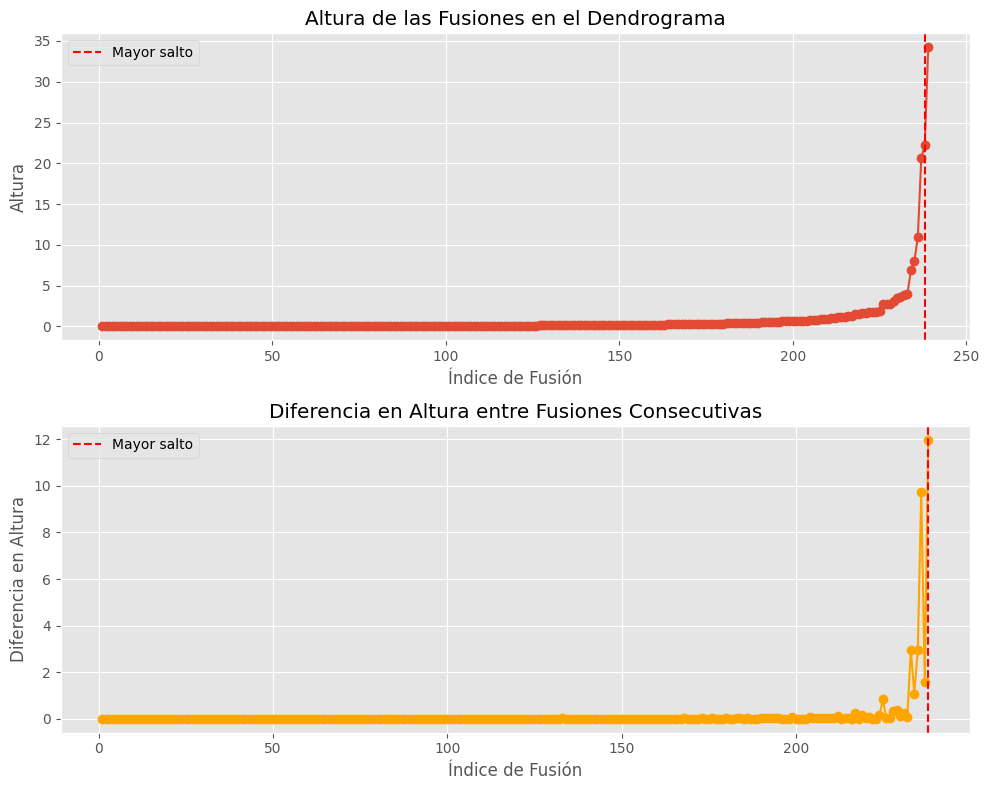

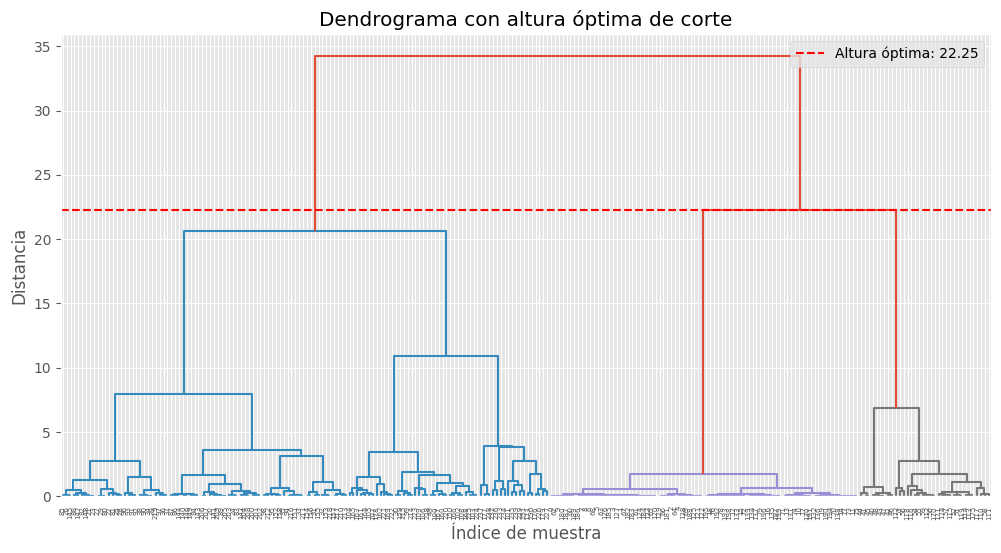

In [13]:
# Detección automática del salto máximo en las alturas de fusión (linkage ward)

# Usamos ward porque produce los mejores clusters según los dendrogramas
Z = sch.linkage(X_pca, method='ward')

# Extraemos las alturas de fusión
heights = Z[:, 2]

# Calculamos las diferencias entre alturas consecutivas
diffs = np.diff(heights)

# Índice donde ocurre el mayor salto en altura
idx_max_jump     = np.argmax(diffs)
altura_optima    = heights[idx_max_jump]
n_clusters_salto = len(heights) - idx_max_jump

print(f"Número óptimo de clusters según salto máximo: {n_clusters_salto}")
print(f"Altura de corte óptima: {altura_optima:.4f}")

# Gráficos del salto
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].plot(range(1, len(heights) + 1), heights, marker='o', linestyle='-')
ax[0].axvline(x=idx_max_jump + 1, color='r', linestyle='--', label='Mayor salto')
ax[0].set_title('Altura de las Fusiones en el Dendrograma')
ax[0].set_xlabel('Índice de Fusión')
ax[0].set_ylabel('Altura')
ax[0].legend()

ax[1].plot(range(1, len(diffs) + 1), diffs, marker='o', linestyle='-', color='orange')
ax[1].axvline(x=idx_max_jump + 1, color='r', linestyle='--', label='Mayor salto')
ax[1].set_title('Diferencia en Altura entre Fusiones Consecutivas')
ax[1].set_xlabel('Índice de Fusión')
ax[1].set_ylabel('Diferencia en Altura')
ax[1].legend()

plt.tight_layout()
plt.show()

# Dendrograma con la altura de corte marcada
plt.figure(figsize=(12, 6))
sch.dendrogram(Z, color_threshold=altura_optima)
plt.axhline(
    y         = altura_optima,
    color     = 'r',
    linestyle = 'dashed',
    label     = f'Altura óptima: {altura_optima:.2f}'
)
plt.title('Dendrograma con altura óptima de corte')
plt.xlabel('Índice de muestra')
plt.ylabel('Distancia')
plt.legend()
plt.show()

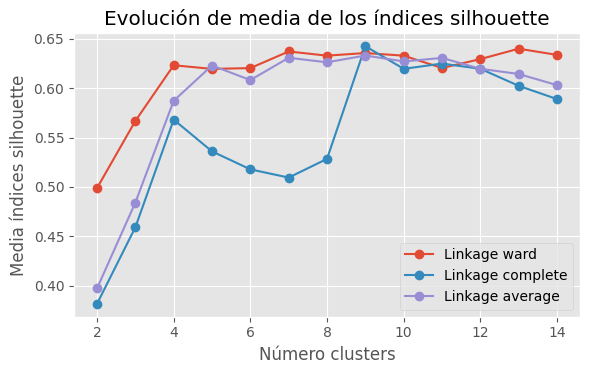

Mejor linkage:             complete
Número óptimo de clusters: 9
Silhouette score máximo:   0.6426


In [14]:
# Método Silhouette para los tres linkages

range_n_clusters = range(2, 15)
linkages         = ['ward', 'complete', 'average']
resultados_sil   = {l: [] for l in linkages}

for linkage in linkages:
    for n_clusters in range_n_clusters:
        modelo = AgglomerativeClustering(
            metric     = 'euclidean',
            linkage    = linkage,
            n_clusters = n_clusters
        )
        cluster_labels = modelo.fit_predict(X_pca)
        silhouette_avg = silhouette_score(X_pca, cluster_labels)
        resultados_sil[linkage].append(silhouette_avg)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
for linkage in linkages:
    ax.plot(
        range_n_clusters,
        resultados_sil[linkage],
        marker = 'o',
        label  = f'Linkage {linkage}'
    )

ax.set_title('Evolución de media de los índices silhouette')
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette')
ax.legend()
plt.tight_layout()
plt.show()

# Mejor combinación linkage + n_clusters
mejor_linkage  = max(resultados_sil, key=lambda l: max(resultados_sil[l]))
mejor_k_hclust = list(range_n_clusters)[np.argmax(resultados_sil[mejor_linkage])]
mejor_score    = max(resultados_sil[mejor_linkage])

print(f"Mejor linkage:             {mejor_linkage}")
print(f"Número óptimo de clusters: {mejor_k_hclust}")
print(f"Silhouette score máximo:   {mejor_score:.4f}")

In [15]:
# Cálculo adicional para justificar la elección de Ward con K=7 frente a otros valores
valores_k = [4, 6, 7, 13]

for k in valores_k:
    modelo = AgglomerativeClustering(
        metric     = 'euclidean',
        linkage    = 'ward',
        n_clusters = k
    )
    labels = modelo.fit_predict(X_pca)
    score  = silhouette_score(X_pca, labels)
    print(f"Ward con K={k:>2} — Silhouette score: {score:.4f}")

# Comparamos también con la mejor combinación detectada automáticamente
modelo_complete = AgglomerativeClustering(
    metric     = 'euclidean',
    linkage    = 'complete',
    n_clusters = 9
)
labels_complete = modelo_complete.fit_predict(X_pca)
score_complete  = silhouette_score(X_pca, labels_complete)
print(f"\nComplete con K=9 — Silhouette score: {score_complete:.4f}")

Ward con K= 4 — Silhouette score: 0.6233
Ward con K= 6 — Silhouette score: 0.6204
Ward con K= 7 — Silhouette score: 0.6373
Ward con K=13 — Silhouette score: 0.6401

Complete con K=9 — Silhouette score: 0.6426


El análisis del salto máximo en las alturas de fusión (Ward) identifica 2 clusters como número óptimo, con una altura de corte de 22.25 . Sin embargo, como vemos en el dendrograma con dicha altura de corte, el resultado visual produce 3 grupos diferenciados, lo que sugiere que el criterio del salto máximo es demasiado conservador para este dataset.

En cuanto al Silhouette, el código identifica automáticamente Linkage Complete con K=9 como la mejor combinación (score=0.6426). Sin embargo, analizando las curvas en detalle, Ward es la seria más alta y estable a lo largo de todo el rango, manteniéndose entre 0.61 y 0.64 desde K=4 en adelante, mientras que Complete parte de valores muy bajos en K=2 (0.38 aprox) y su trayectoria es más irregular.

Para confirmar, calculamos los scores exactos de Ward para distintos valores de K, obteniendo que K=7 alcanza un Silhouette de 0.6373, notablemente superior al de K=6 (0.6204) y muy cercano al máximo global Complete K=9 (0.6426), con la ventaja de producir clusters más compactos e interpretables gracias a la robustez de Ward.

Por tanto, elegimos Ward con K=7 como configuración final del Clustering Jerárquico ya que ofrece el mejor equilibrio entre calidad de clustering (score=0.6373), interpretabilidad (7 clusters para 240 estrellas) y robustez estructural (dendrograma más limpio).

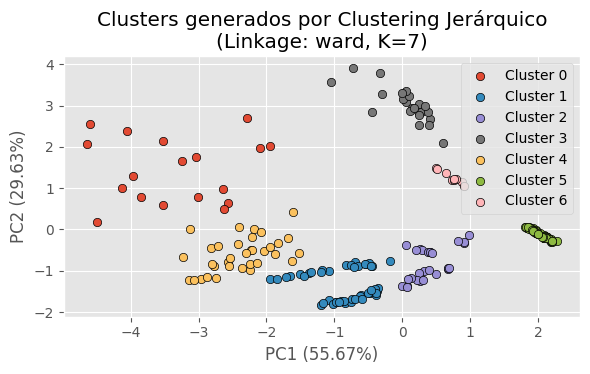

Clustering Jerárquico — Linkage: ward, K=7
Silhouette score: 0.6373


In [16]:
# Modelo final de Clustering Jerárquico linkage = ward y K = 7
modelo_hclust_final = AgglomerativeClustering(
    metric     = 'euclidean',
    linkage    = 'ward',
    n_clusters = 7
)

labels_hclust = modelo_hclust_final.fit_predict(X_pca)

# Visualización de los clusters
fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))

for i in np.unique(labels_hclust):
    ax.scatter(
        x         = X_pca[labels_hclust == i, 0],
        y         = X_pca[labels_hclust == i, 1],
        marker    = 'o',
        edgecolor = 'black',
        label     = f'Cluster {i}'
    )

ax.set_title(
    f'Clusters generados por Clustering Jerárquico\n'
    f'(Linkage: ward, K=7)'
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.legend()
plt.tight_layout()
plt.show()

# Métrica final
silhouette_hclust = silhouette_score(X_pca, labels_hclust)
print("Clustering Jerárquico — Linkage: ward, K=7")
print(f"Silhouette score: {silhouette_hclust:.4f}")

**Conclusiones clustering jerárquico**

El Clustering Jerárquico con Linkage Ward y K=7 ha obtenido un Silhouette score de 0.6373, ligeramente inferior al de K-Means (0.6373 vs 0.6501), aunque ambos son comparables en calidad.

Observando la visualización, la separación general entre clusters es buena y coherente con el score obtenido. Destacan varios patrones:
- Algunos clusters son muy compactos y bien definidos, como el Cluster 2 (morado, zona inferior-derecha), con baja dispersión interna y bien separado del resto.

- Otros clusters son más dispersos, como el Cluster 0 (rojo, zona superior-izquierda), que ocupa una región amplia con puntos muy esparcidos, y el Cluster 4 (naranja, zona central), que se solapa parcialmente con el Cluster 1 (azul).

- Los Clusters 5 (verde) y 6 (rosa) son muy pequeños, lo que podría indicar subgrupos minoritarios o tipos de estrellas poco frecuentes en el dataset.

A diferencia de K-Means, el Clustering Jerárquico no asume formas esféricas para los clusters, lo que le permite capturar estructuras más irregulares. Sin embargo, la presencia de clusters muy pequeños como el 5 y el 6 sugiere que Ward con K=7 podría estar sobreparticionando algunas regiones del espacio PCA. Comprobaremos si DBSCAN, al estar basado en densidad, obtiene una separación más natural e identifica outliers explícitos.

### 3.3. CLustering: DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo basado en densidad. A diferencia de K-Means y el Clustering Jerárquico, no necesita que se especifique el número de clusters y es capaz de identificar outliers explícitamente (puntos que no pertenecen a ningún cluster, etiquetados como -1).

Sus dos hiperparámetros principales son:
- **`eps`**: radio del vecindario de cada punto. Define qué se entiende por "región densa".

- **`min_samples`**: número mínimo de puntos en el vecindario para uqe un punto sea considerado core point. Para datos bidimensionales, el valor recomendado para min_samples = 4.

Para elegir eps usareos la heurística k-distance: calculamos la distancia de cada punto a su k-ésimo vecino más cercano (con k=min_samples), las ordenamos y buscamos el "codo" de la curva, que indica el valor óptimo de eps. Posteriormente evaluaremos distintas convinaciones de hiperparámetros con la métrica DBCV, específicamente diseñada para evaluar clusteres basados en densidad.

In [17]:
# Instalación de la métrica DBCV (no disponible en scikit-learn)
%pip install "git+https://github.com/FelSiq/DBCV"

  Cloning https://github.com/FelSiq/DBCV to C:\Users\Xiya\AppData\Local\Temp\pip-req-build-toj34ddz
  Resolved https://github.com/FelSiq/DBCV to commit 13c3896ef78d12f1e3e1cbd394f2db9a09637ffd
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/FelSiq/DBCV 'C:\Users\Xiya\AppData\Local\Temp\pip-req-build-toj34ddz'

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


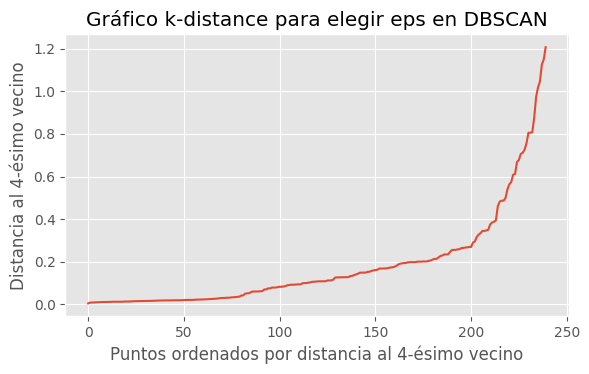

In [18]:
# Gráfico k-distance para elegir eps


# Para datos 2D, min_samples recomendado = 4
min_samples = 4

# Calculamos los vecinos más cercanos
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_pca)
distances, indices = nn.kneighbors(X_pca)

# Ordenamos las distancias al k-ésimo vecino
sorted_distances = np.sort(distances[:, min_samples - 1], axis=0)

# Gráfico
fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(sorted_distances)
ax.set_xlabel(f'Puntos ordenados por distancia al {min_samples}-ésimo vecino')
ax.set_ylabel(f'Distancia al {min_samples}-ésimo vecino')
ax.set_title('Gráfico k-distance para elegir eps en DBSCAN')
ax.grid(True)
plt.tight_layout()
plt.show()

El gráfico k-distance muestra una curva muy característica. La curva permanece prácticamente plana (distancias entre 0.0 y 0.1) para los primeros 100 puntos, lo que indica una zona de alta densidad. A partir del punto 200 aprox se produce una inflexión más pronunciada, disparándose hasta el 1.2 aprox en los últimos puntos.

El "codo" se sitúa en torno a eps = 0.25-0.30, que es donde comienza la subida brusca. Los puntos por encima de este umbral (tramo final de la curva) son candidatos a ser considerados outliers por DBSCAN.

Exploraremos valores de eps en torno a este rango en el grid de hiperparámetros, evaluando los clusters resultantes con la métrica DBCV.

In [19]:
# Grid de hiperparámetros para DBSCAN evaluado con DBCV

import dbcv

# Definimos los valores a explorar alrededor del eps heurístico
# (ajusta eps_values según el codo que hayas visto en el gráfico)
min_samples_values = [3, 4, 5]
eps_values         = [0.20, 0.25, 0.30, 0.35, 0.40]

print(f"{'MS':<3} | {'EPS':<4} | {'Nº Clusters':<11} | {'% Ruido':<8} | {'DBCV Score'}")
print("-" * 55)

for ms in min_samples_values:
    for eps in eps_values:
        # Ejecutamos DBSCAN
        db     = DBSCAN(eps=eps, min_samples=ms).fit(X_pca)
        labels = db.labels_

        # Contamos clusters (excluyendo ruido -1)
        n_clusters = len(set(labels) - {-1})

        # Calculamos % de ruido
        n_noise    = list(labels).count(-1)
        perc_noise = (n_noise / len(labels)) * 100

        # Calculamos DBCV si hay más de 1 cluster
        if n_clusters > 1:
            score = dbcv.dbcv(X_pca, labels)
            print(f"{ms:<3} | {eps:<4} | {n_clusters:<11} | {perc_noise:>7.1f}% | {score:.4f}")
        else:
            print(f"{ms:<3} | {eps:<4} | {n_clusters:<11} | {perc_noise:>7.1f}% | No calculable")

MS  | EPS  | Nº Clusters | % Ruido  | DBCV Score
-------------------------------------------------------
3   | 0.2  | 13          |    15.4% | 0.7792
3   | 0.25 | 13          |    13.3% | 0.7754
3   | 0.3  | 9           |    12.5% | 0.7214
3   | 0.35 | 9           |     9.6% | 0.7375
3   | 0.4  | 9           |     7.9% | 0.6319
4   | 0.2  | 12          |    18.8% | 0.7511
4   | 0.25 | 13          |    13.8% | 0.7763
4   | 0.3  | 9           |    12.5% | 0.7214
4   | 0.35 | 8           |    11.2% | 0.7269
4   | 0.4  | 7           |    10.8% | 0.6067
5   | 0.2  | 9           |    27.5% | 0.6935
5   | 0.25 | 11          |    17.5% | 0.7468
5   | 0.3  | 8           |    14.2% | 0.7057
5   | 0.35 | 8           |    13.3% | 0.7111
5   | 0.4  | 6           |    12.5% | 0.5909


La tabla DBCV muestra que el mejor score global corresponde a ms=3, eps=0.20 (DBCV=0.7792), sin embargo, min_samples=3 está por debajo del valor teóricamente recomendado para datos bidimensionales (min_samples=2 * dimensiones=4), lo que puede generar clusters poco robustos y más sensibles al ruido.

Analizando las configuraciones con min_samples=4, el mejor resultado es eps=0.25 con un DBCV de 0.7763, prácticamente idéntico al máximo global (diferencia del solo 0.0029) y con un porcentaje de ruido razonable (13,8%).

Por tanto, elegimos ms=4, eps=0.25 como configuración final, ya que ofrece el mejor equilibrio entre calidad de clustering (0.7792), robustez teórica (min_samples recomendado para 2D) y un nivel de ruido aceptable.

Número de clusters encontrados: 13
Número de outliers encontrados: 33 (13.8%)


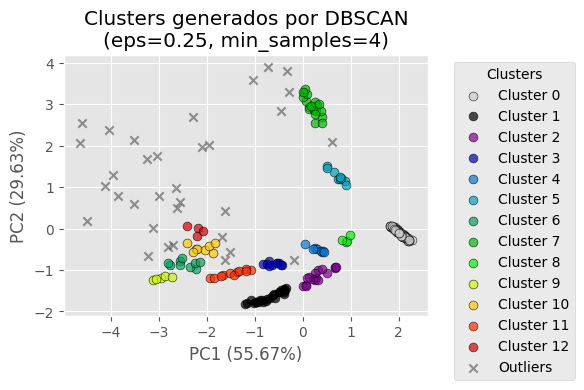


DBSCAN — eps=0.25, min_samples=4
DBCV score: 0.7763


In [20]:
# Modelo final DBSCAN con los hiperparámetros óptimos

EPS_OPTIMO         = 0.25  
MIN_SAMPLES_OPTIMO = 4     

modelo_dbscan_final = DBSCAN(
    eps         = EPS_OPTIMO,
    min_samples = MIN_SAMPLES_OPTIMO,
    metric      = 'euclidean'
)
modelo_dbscan_final.fit(X=X_pca)

# Etiquetas
labels_dbscan = modelo_dbscan_final.labels_

# Número de clusters y outliers
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_dbscan    = list(labels_dbscan).count(-1)

print(f'Número de clusters encontrados: {n_clusters_dbscan}')
print(f'Número de outliers encontrados: {n_noise_dbscan} '
      f'({(n_noise_dbscan/len(labels_dbscan))*100:.1f}%)')

# Definimos una paleta de colores más variada para que no se repitan
cluster_ids_reales = sorted([i for i in np.unique(labels_dbscan) if i != -1])
n_clusters = len(cluster_ids_reales)
colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_clusters))

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))

for i, cluster_id in enumerate(cluster_ids_reales):
    if i == -1:
        continue
    ax.scatter(
        x         = X_pca[labels_dbscan == cluster_id, 0],
        y         = X_pca[labels_dbscan == cluster_id, 1],
        c         = [colors[i-1]],
        marker    = 'o',
        edgecolor = 'black',
        s         = 40,
        label     = f'Cluster {cluster_id}',
        alpha     = 0.7
    )

# Outliers en rojo
ax.scatter(
    x         = X_pca[labels_dbscan == -1, 0],
    y         = X_pca[labels_dbscan == -1, 1],
    c         = '#333333',
    marker    = 'x',
    label     = 'Outliers',
    alpha     = 0.5
)

ax.set_title(
    f'Clusters generados por DBSCAN\n'
    f'(eps={EPS_OPTIMO}, min_samples={MIN_SAMPLES_OPTIMO})'
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Clusters")
plt.tight_layout()
plt.show()

# DBCV del modelo final
score_dbscan = dbcv.dbcv(X_pca, labels_dbscan)
print(f'\nDBSCAN — eps={EPS_OPTIMO}, min_samples={MIN_SAMPLES_OPTIMO}')
print(f'DBCV score: {score_dbscan:.4f}')

**Conclusiones de DBSCAN**

DBSCAN con eps=0.25 y min_samples=4 ha obtenido un DBCV score de 0.7763, notablemente superior al Silhouette de K-Means (0.6501) y al Clustering Jerárquico (0.6373). Sin embargo, hay que tener en cuenta que DBCV y Silhouette son métricas distintas y no directamente comparables, ya que DBCV está específicamente diseñada para evaluar clusters basados en densidad.

El resultado visual muestra 13 clusters y aproximadamente 33 outliers (13,8%), lo que revela una fragmentación excesiva del espacio PCA. La mayoría de clusters son muy pequeños (5-15 puntos) y se concentran en una o dos bandas en la zona central del gráfico, mientras que los outliers aparecen dispersos especialmente en la zona izquierda.

Esto pone de manifiesto la principal limitación de DBSCAN: es muy sensible a la elección de eps y min_samples. Con eps=0.25 los parámetros resultan demasiado restrictivos para el dataset, identificando como clusters separados lo que probablemente son subgrupos del mismo tipo estelar. Por otro lado, la capacidad de DBSCAN para detectar outliers explícitos es una ventaja clara frente a K-Means y el Clustering Jerárquico, que asignan todos los puntos a algún cluster sin distinguir posibles anomalías.

A diferencia de K-Means, DBSCAN no asume formas esféricas y puede detectar clusters de cualquier forma. Sin embargo, su mayor debilidad es la dificultad para manejar clusters de densidades muy distintas, como parece ocurrir en este dataset donde conviven zonas muy densas (zona central) con zonas más dispersas (zona izquierda).

## 4. Pipeline de Clustering recomendado
A partir de los resultados obtenidos, hemos deducido que el pipeline y algoritmo recomendados serían los siguientes:

**Pipeline completo:**
1. **Preprocesamiento (codificación):** Al aplicar *OrdinalEncoder* para las variables categóricas (*Color* y *Spectral_Class*), respetando el orden físico basado en la temperatura, tal y como definimos al principio.
2. **Escalado:** *StandardScaler* para estandarizar todas las variables (media 0, varianza 1), que es un paso fundamental antes del PCA.
3. **Reducción de Dimensionalidad:** *PCA* con *n_components=2*.
4. **Algoritmo de Clustering:** K-Means.

**Hiperparámetros del modelo K-Means:**
- *n_clusters = 6*
- *n_init = 25*
- *random_state = SEMILLA*

Esta elección nos parece lo más claro, ya que por un lado hay calidad de agrupación y métricas. K-Means con K=6 obtiene el mejor coeficiente Silhouette (0.6501) en comparación con el Clustering Jerárquico (0.6373 con K=7). Aunque DBSCAN obtiene un buen score DBCV, este fragmenta en exceso el espacio (13 clusters) y descarta casi un 14% de los datos como ruido, lo cual no nos resulta útil para obtener una clasificación general clara. Por otro lado K-Means genera 6 grupos muy bien definidos en el espacio. Además, es el modelo que mejor generaliza la estructura global de los datos en el espacio por PCA, formando grupos compactos sin sobreparticionar artificialmente el dataset.

## 5. Similitudes entre las clases astronómicas y los grupos obtenidos
Sí podemos ver similitudes, empezando por el hecho de que el algoritmo K-Means con K=6 ha logrado redescubrir de forma no supervisada las clasificaciones estelares principales que la astronomía define de manera teórica.

En la tabla proporcionada, se describen exactamente 6 clases de estrellas (Enana roja, Enana marrón, Enana blanca, Estrella en secuencia principal, Super gigante y Hiper gigante)

Nuestro modelo K-Means ha identificado exactamente 6 clusters óptimos basándose en las variables físicas proporcionadas (Temperatura, Luminosidad, Radio, Magnitud Absoluta, Color y Clase Espectral).

Las variables que hemos utilizado para entrenar el modelo son las mismas que los astrónomos utilizan para construir el Diagrama de Hertzsprung-Russell (HR), esto nos clasifica las estrellas empíricamente:
- **Magnitud Absoluta (*A_M*) y Luminosidad (*L*):** SOn clave para separar a las estrellas muy brillantes (Supergigantes e Hipergigantes) de las menos brillantes (Enanas marrones, rojas y blancas).
- **Temperatura, Color y Clase Espectral:** Diferencian las estrellas dentro de un mismo rango de luminosidad (por ejemplo, permiten distinguir una enana blanca, que es muy caliente, de una enana roja, que es mucho más fría).
- **Radio (*R*):** Ayuda a aislar claramente a las Supergigantes e Hipergigantes del resto, ya que su tamaño es varios órdenes de magnitud mayor.

Al aplicar el PCA, la varianza de estas características físicas se proyecta logrando que las diferencias reales entre estos 6 tipos de estrellas formen agrupaciones naturales. Por lo tanto, el hecho de que K-Means encuentre 6 clusters óptimos se debe a que cada cluster generado por el algoritmo se corresponde con muy alta probabilidad a una de las 6 clases físicas de la tabla proporcionada.